In [1]:
%matplotlib inline 

In [2]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_moving_source_only_input" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.45 seconds]


In [3]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-06-11 17:02:50,822] INFO: Loading project from simulation_wavefield_moving_source_only_input.


In [4]:

# Layered model setup: three layers ordered as snow, slab, air (top to bottom).

x_min, x_max = 0.0, 400.0

# Geometry (y-coordinates: higher = higher depth, measured downward):
# Snow: from y=3.0 m (top) to y=2.25 m
# Slab: from y=2.25 m to y=1.5 m  
# Air:  from y=1.5 m to y=0.0 m (bottom)

slab_top = 3.0
slab_bottom = 2.25
wl_top = 2.25
wl_bottom = 1.5
air_top = 1.5
air_bottom = 0.0

# Boundaries from top to bottom -> 3 layers.
# Must be strictly ordered: top to bottom (decreasing y).
layers_x = [
    np.array([x_min, x_max]),  # snow top boundary
    np.array([x_min, x_max]),  # snow-slab interface
    np.array([x_min, x_max]),  # slab-air interface
    np.array([x_min, x_max]),  # air bottom boundary
]
layers_y = [
    np.array([slab_top, slab_top]),      # y = 3.0
    np.array([slab_bottom, slab_bottom]),  # y = 2.25
    np.array([wl_bottom, wl_bottom]),  # y = 1.5
    np.array([air_bottom, air_bottom]),    # y = 0.0
]

# Material parameters by region index [snow, slab, air].
vp = np.array([332.0, 300.0, 300.0]) 
vs = np.array([150.0, 150.0, 0.0])   
rho = np.array([180.0, 180.0, 1.225])

interpolation_styles = ["linear"] * len(layers_x)
splines = sn.toolbox.get_interpolating_splines(layers_x, layers_y, kind=interpolation_styles)
 
max_frequency = np.percentile([vp[0], vp[1], vp[2]], 95) # set this as the 95th percentile of the expected frequency content
print(f"Max frequency for meshing: {max_frequency:.1f} Hz")
# One per layer pair; last value keeps meshing stable above acoustic air.
slowest_velocities = np.array([150.0, 150.0,  150.0])

mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    absorbing_boundaries=(["x0", "x1", "y0"], 10.0),
)
mesh = np.sum(mesh)
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)

nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    idx = np.where(mesh.elemental_fields["region"] == _i)
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

mesh_3layer = sn.toolbox.detect_fluid(mesh)
print("Three-layer mesh built.")
print(f"  SLab: y = [{slab_top:.2f}, {slab_bottom:.2f}] m, vs={vs[0]:.0f} m/s")
print(f"  Weak layer: y = [{wl_top:.2f}, {wl_bottom:.2f}] m, vs={vs[1]:.0f} m/s")
print(f"  Air layer:  y = [{air_top:.2f}, {air_bottom:.2f}] m, vs={vs[2]:.0f} m/s")


Max frequency for meshing: 328.8 Hz
Three-layer mesh built.
  SLab: y = [3.00, 2.25] m, vs=150 m/s
  Weak layer: y = [2.25, 1.50] m, vs=150 m/s
  Air layer:  y = [1.50, 0.00] m, vs=0 m/s


In [5]:
# Moving source setup: all source locations in ONE event (not one event per location).
lambda_min = min(vs[vs > 0]) / max_frequency
print(f"Minimum wavelength to resolve: {lambda_min:.2f} m")

# Have about 5 to 10 sources per wavelength for a physical crack representation.
steps = 0.5  # m spacing
x_positions = np.arange(30.0, 270.0, 0.5)


# Keep source in snow layer.
y_source = 2.625

# Sub-Rayleigh rupture speed target for source delays.
target_vprop = 90  # m/s (slower than vs=150 m/s for subrayleigh)
dx = x_positions[1] - x_positions[0]
dt_src = dx / target_vprop
source_delays = np.arange(len(x_positions)) * dt_src

source_strengths_xy = []
source_strengths_yy = []
srcs = []

for i, x_pos in enumerate(x_positions):
    src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
        x=float(x_pos),
        y=y_source,
        mxx=0.0,
        myy=-1.54e+01,
        mxy=0.0,
    )
    srcs.append(src)
    source_strengths_xy.append(0.0)
    source_strengths_yy.append(-1.54e+01)

moving_source_event_name = "event_wavefield_output_all_sources"

# Re-runnable pattern: replace existing event explicitly, then add the updated one.
if moving_source_event_name in p.events.list():
    p.events.delete(event_name=moving_source_event_name)


print(f"Added event '{moving_source_event_name}' with {len(srcs)} sources.")
print(f"Source delays span {source_delays[0]:.2f}s to {source_delays[-1]:.2f}s.")
print(f"Initial source magnitudes: mxy={source_strengths_xy[0]:.2f}, myy={source_strengths_yy[0]:.2f}")
if len(source_strengths_xy) > 1:
    print(f"First crack source magnitudes: mxy={source_strengths_xy[1]:.2f}, myy={source_strengths_yy[1]:.2f}")
    print(f"Last crack source magnitudes: mxy={source_strengths_xy[-1]:.2f}, myy={source_strengths_yy[-1]:.2f}")

Minimum wavelength to resolve: 0.46 m
Added event 'event_wavefield_output_all_sources' with 480 sources.
Source delays span 0.00s to 2.66s.
Initial source magnitudes: mxy=0.00, myy=-15.40
First crack source magnitudes: mxy=0.00, myy=-15.40
Last crack source magnitudes: mxy=0.00, myy=-15.40


In [6]:
# One simulation configuration for the one-event moving-source setup.
moving_source_simulation_name = "sim_2d_layered_moving_source_all"
#forced_solver_dt = 0.00001 # to try and force salvus to use a smaller internal timestep in the solver 
# # maximum delay accounting for simulation time needed 
# max_delay = float(source_delays[-1])
# needed_end_time = 0.3 + max_delay + 2.0
p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        name=moving_source_simulation_name,
        unstructured_mesh=mesh_3layer,
        event_configuration=sn.EventConfiguration(
            # Dummy STF at config level; replaced per source below.
            wavelet=sn.simple_config.stf.Delta(),
            waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                start_time_in_seconds=-0.3,
                end_time_in_seconds=3.0,
                # time_step_in_seconds=forced_solver_dt,
            ),
        ),
    ),
    overwrite=True,
)

# Use the waveform template API instead of get_input_files().  avoids  event-output validation while givingeditable waveform template
input_file = p.simulations.get_simulation_template(
    moving_source_simulation_name,
    moving_source_event_name,
)

# Seed the template with the actual sources from the event.
input_file.add_sources(srcs)

if len(input_file.physics.wave_equation.point_source) != len(source_delays):
    raise ValueError(
        f"Mismatch between input-file sources ({len(input_file.physics.wave_equation.point_source)}) and delays ({len(source_delays)})."
    )

# Rebuild and overwrite the list to force Salvus backend serialization
updated_point_sources = []

for i, src in enumerate(input_file.physics.wave_equation.point_source):
    # Dynamically bind the correct center frequency and independent delayed time shift
    src.source_time_function = sn.simple_config.stf.Ricker(
        center_frequency=10,
        time_shift_in_seconds=0.3 + float(source_delays[i]),
    )
    updated_point_sources.append(src)

# Overwriting the top-level property directly forces the Mondaic/Salvus data layer 
# to flag the array as "dirty" and write all 2,400 updates out to disk.
input_file.physics.wave_equation.point_source = updated_point_sources

# Safely call file-save if exposed by your specific Salvus API version wrapper
if hasattr(input_file, "save"):
    input_file.save()


# Remove point-output from this volume-only run.
del input_file.output.point_data

# Request volume output once for the combined run.
input_file.output.volume_data = {
    "filename": "volume_data_output.h5",
    "format": "hdf5",
    "fields": ["velocity", "displacement"],
    "sampling_interval_in_time_steps": 50,
}
input_file.validate()

print(f"Prepared '{moving_source_simulation_name}' for event '{moving_source_event_name}'.")
print(f"Assigned and successfully serialized {len(source_delays)} delayed wavelets in one event structure.")

[2026-06-11 17:02:58,918] INFO: This exact entity is already part of the project. Nothing will be done. The comparison to the existing mesh was fairly expensive as it is (depending on the mesh size) a large amount of data that has to be compared. So best only add it once!
Prepared 'sim_2d_layered_moving_source_all' for event 'event_wavefield_output_all_sources'.
Assigned and successfully serialized 480 delayed wavelets in one event structure.


In [7]:
# Launch one combined simulation containing all delayed source wavelets in one event.
check_license_server_reachable()
print(f"Submitting combined moving-source run on site='{SALVUS_FLOW_SITE_NAME}' with ranks={RANKS_PER_JOB}")

# Write run outputs into the project directory.
moving_source_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")
moving_source_job = sn.api.run(
    input_file=input_file,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=moving_source_output_folder,
    get_all=True,
    overwrite=True,
 )

print(f"Run finished. Output folder: {moving_source_output_folder}")

Submitting combined moving-source run on site='salome_remote_2' with ranks=4
SalvusJob `job_2606111021989590_d5c2925559` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/52534 [00:00<?, ?it/s]

* Downloaded 7.1 GB of results to `simulation_wavefield_moving_source_only_input/custom_job_moving_source_all_sources`.
* Total run time: 328.53 seconds.
* Pure simulation time: 318.85 seconds.
Run finished. Output folder: simulation_wavefield_moving_source_only_input/custom_job_moving_source_all_sources


In [7]:
# Extract velocity wavefield output from the single combined run.
vol_file = pathlib.Path("/mnt/sda/salome/heavy-workspace/Test Simulations/simulation_wavefield_moving_source_only_input/custom_job_moving_source_all_sources/volume_data_output.h5")
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

vel_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "velocity",
    "volume",
)

vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

print(f"Loaded velocity from {vol_file}")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-06-11 17:04:41,595] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded velocity from /mnt/sda/salome/heavy-workspace/Test Simulations/simulation_wavefield_moving_source_only_input/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 1052, c: 2, x: 401, y: 101)> Size: 341MB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.0

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.3 -> 3.00100506338752
vx shape: (1052, 401)
vy shape: (1052, 401)


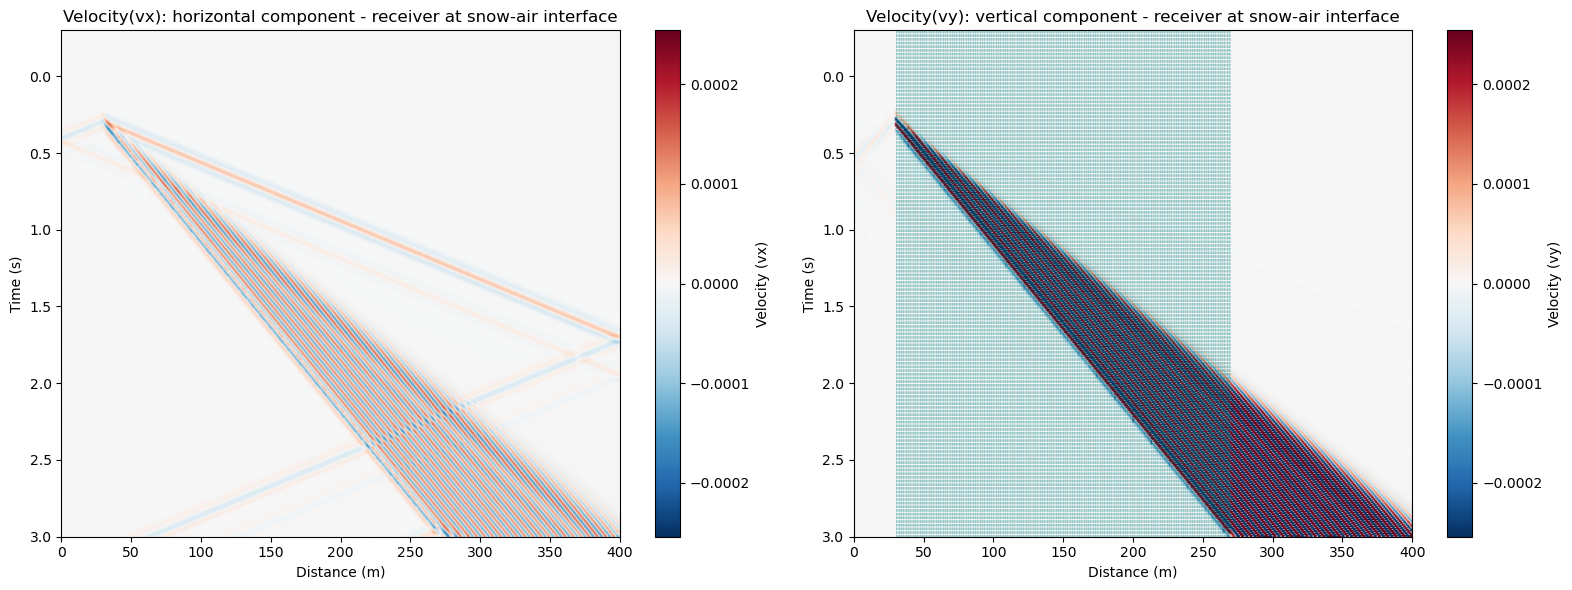

In [ ]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # This would be at snow-air boundary 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx): horizontal component - receiver at crakc interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# Mark all moving source positions
for x_src in x_positions:
    axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy): vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)